In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ocean_acidity_preprocessed.csv to ocean_acidity_preprocessed.csv


In [3]:
df = pd.read_csv("ocean_acidity_preprocessed.csv")

In [4]:
df.head()

,lat,lon,SST,WOA_SSS,NCEP_SLP,ETOPO2_depth,dist_to_land,PPPP,xCO2water_SST_dry,shipping_proxy,...,month_sin,month_cos,day_of_year,abs_lat,hemisphere,SST_salinity_interaction,pressure_diff,fCO2_per_SST,acidity_level,acidity_level_encoded
0,0.362540,-0.789310,1.534968,-1.983290,0.542119,-1.044723,-0.786616,0.814255,-2.273737e-13,-0.124614,...,-0.663714,-1.206547,0.058793,-0.726698,0.727595,1.269760,0.368674,0.101998,Vulnerable,2
1,0.817438,-0.009803,0.126831,0.627816,1.184172,-1.030758,-0.816119,1.588199,-2.273737e-13,-0.112494,...,0.032588,-1.399309,-0.058075,0.335412,0.727595,0.173181,0.350767,-0.002158,Safe,1
2,0.169624,1.548770,1.496223,0.234853,-0.186698,0.360768,1.635337,-0.203535,-2.273737e-13,-0.211089,...,-0.663714,-1.206547,0.195139,-1.177125,0.727595,1.469165,0.153796,0.100561,Vulnerable,2
3,1.537433,0.398439,-1.569480,-1.072989,0.741676,0.871493,0.117258,0.814255,-2.273737e-13,-0.198878,...,-1.173443,-0.679912,0.555481,2.016476,0.727595,-1.473767,-0.043176,-0.754649,Safe,1
4,0.893610,-1.472975,-0.694410,-1.417118,-0.568459,1.053039,-0.282378,-0.945673,-2.273737e-13,-0.187627,...,0.728890,-1.206547,-0.291810,0.513260,0.727595,-0.681994,-0.311773,0.261069,Vulnerable,2


In [5]:
df.tail()

,lat,lon,SST,WOA_SSS,NCEP_SLP,ETOPO2_depth,dist_to_land,PPPP,xCO2water_SST_dry,shipping_proxy,...,month_sin,month_cos,day_of_year,abs_lat,hemisphere,SST_salinity_interaction,pressure_diff,fCO2_per_SST,acidity_level,acidity_level_encoded
149995,0.632625,-0.608416,-0.828490,-1.852048,0.264475,-0.997840,-0.513040,0.361550,-2.273737e-13,-0.173502,...,1.238619,-0.679912,-0.681369,-0.096097,0.727595,-0.812202,0.177074,-0.288543,Safe,1
149996,0.773505,-0.351291,0.470904,-0.287063,0.377268,0.763263,0.964808,0.019106,-2.273737e-13,-0.207964,...,-1.360017,0.039485,0.886606,0.232834,0.727595,0.446831,-0.634090,-0.091327,Safe,1
149997,-1.648984,-0.545380,-1.390444,0.361517,-2.112856,-0.795845,-0.969000,-1.899851,-2.273737e-13,0.092666,...,0.032588,1.478279,1.743635,1.020500,-1.374390,-1.308817,-0.104058,0.548584,Vulnerable,2
149998,0.598335,-1.193391,-0.272649,-1.414066,0.602854,0.391192,-0.690060,1.230488,-2.273737e-13,-0.150368,...,0.728890,-1.206547,-0.467112,-0.176157,0.727595,-0.301200,0.946337,-0.094058,Safe,1
149999,-1.511501,-0.345494,-1.522552,-0.505291,0.646236,0.379720,1.538781,-0.551280,-2.273737e-13,-0.210738,...,0.032588,-1.399309,-0.067814,0.699502,-1.374390,-1.433096,-2.152560,0.320559,Vulnerable,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   lat                       150000 non-null  float64
 1   lon                       150000 non-null  float64
 2   SST                       150000 non-null  float64
 3   WOA_SSS                   150000 non-null  float64
 4   NCEP_SLP                  150000 non-null  float64
 5   ETOPO2_depth              150000 non-null  float64
 6   dist_to_land              150000 non-null  float64
 7   PPPP                      150000 non-null  float64
 8   xCO2water_SST_dry         150000 non-null  float64
 9   shipping_proxy            150000 non-null  float64
 10  is_coastal                150000 non-null  float64
 11  shipping_intensity        150000 non-null  float64
 12  month_sin                 150000 non-null  float64
 13  month_cos                 150000 non-null  f

In [7]:
df = df.drop(columns=['lat','lon'])

In [9]:
df["ocean_zone"] = pd.cut(
    df["abs_lat"],
    bins=[0,23.5,66.5,90],
    labels=["Tropical","Temperate","Polar"]
)

In [10]:
df["coastal_shipping_pressure"] = df["shipping_intensity"] * df["is_coastal"]

In [11]:
df["temp_depth_interaction"] = df["SST"] * df["ETOPO2_depth"]

In [12]:
df["co2_shipping_interaction"] = df["xCO2water_SST_dry"] * df["shipping_intensity"]

In [13]:
df["seasonal_productivity"] = df["PPPP"] * df["month_sin"]

In [14]:
df

,SST,WOA_SSS,NCEP_SLP,ETOPO2_depth,dist_to_land,PPPP,xCO2water_SST_dry,shipping_proxy,is_coastal,shipping_intensity,...,SST_salinity_interaction,pressure_diff,fCO2_per_SST,acidity_level,acidity_level_encoded,ocean_zone,coastal_shipping_pressure,temp_depth_interaction,co2_shipping_interaction,seasonal_productivity
0,1.534968,-1.983290,0.542119,-1.044723,-0.786616,0.814255,-2.273737e-13,-0.124614,0.0,-0.124614,...,1.269760,0.368674,0.101998,Vulnerable,2,NaN,-0.0,-1.603617,2.833403e-14,-0.540432
1,0.126831,0.627816,1.184172,-1.030758,-0.816119,1.588199,-2.273737e-13,-0.112494,0.0,-0.112494,...,0.173181,0.350767,-0.002158,Safe,1,Tropical,-0.0,-0.130732,2.557824e-14,0.051756
2,1.496223,0.234853,-0.186698,0.360768,1.635337,-0.203535,-2.273737e-13,-0.211089,0.0,-0.211089,...,1.469165,0.153796,0.100561,Vulnerable,2,NaN,-0.0,0.539789,4.799598e-14,0.135089
3,-1.569480,-1.072989,0.741676,0.871493,0.117258,0.814255,-2.273737e-13,-0.198878,0.0,-0.198878,...,-1.473767,-0.043176,-0.754649,Safe,1,Tropical,-0.0,-1.367790,4.521952e-14,-0.955481
4,-0.694410,-1.417118,-0.568459,1.053039,-0.282378,-0.945673,-2.273737e-13,-0.187627,0.0,-0.187627,...,-0.681994,-0.311773,0.261069,Vulnerable,2,Tropical,-0.0,-0.731241,4.266135e-14,-0.689292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,-0.828490,-1.852048,0.264475,-0.997840,-0.513040,0.361550,-2.273737e-13,-0.173502,0.0,-0.173502,...,-0.812202,0.177074,-0.288543,Safe,1,NaN,-0.0,0.826701,3.944989e-14,0.447823
149996,0.470904,-0.287063,0.377268,0.763263,0.964808,0.019106,-2.273737e-13,-0.207964,0.0,-0.207964,...,0.446831,-0.634090,-0.091327,Safe,1,Tropical,-0.0,0.359424,4.728565e-14,-0.025985
149997,-1.390444,0.361517,-2.112856,-0.795845,-0.969000,-1.899851,-2.273737e-13,0.092666,0.0,0.092666,...,-1.308817,-0.104058,0.548584,Vulnerable,2,Tropical,0.0,1.106577,-2.106981e-14,-0.061912
149998,-0.272649,-1.414066,0.602854,0.391192,-0.690060,1.230488,-2.273737e-13,-0.150368,0.0,-0.150368,...,-0.301200,0.946337,-0.094058,Safe,1,NaN,-0.0,-0.106658,3.418962e-14,0.896891


In [15]:
df = pd.get_dummies(df, columns=["hemisphere","ocean_zone"], drop_first=True)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

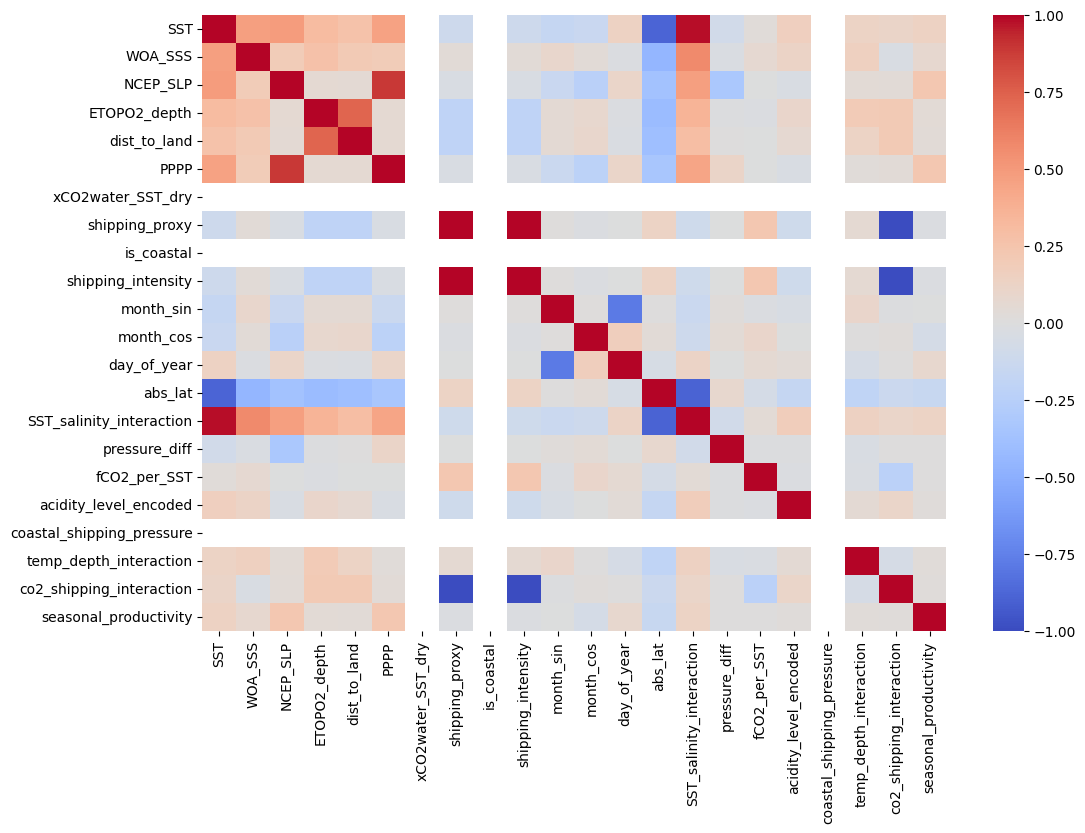

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [19]:
X = df.drop(columns=["acidity_level","acidity_level_encoded"])
y = df["acidity_level_encoded"]

In [20]:
df.shape

(150000, 26)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   SST                            150000 non-null  float64
 1   WOA_SSS                        150000 non-null  float64
 2   NCEP_SLP                       150000 non-null  float64
 3   ETOPO2_depth                   150000 non-null  float64
 4   dist_to_land                   150000 non-null  float64
 5   PPPP                           150000 non-null  float64
 6   xCO2water_SST_dry              150000 non-null  float64
 7   shipping_proxy                 150000 non-null  float64
 8   is_coastal                     150000 non-null  float64
 9   shipping_intensity             150000 non-null  float64
 10  month_sin                      150000 non-null  float64
 11  month_cos                      150000 non-null  float64
 12  day_of_year                   

In [22]:
df.to_csv("ocean_acidity_feature_engineered.csv", index=False)

In [23]:
from google.colab import files
files.download("ocean_acidity_feature_engineered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>